In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
from collections import defaultdict
import json

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR = BUNDLE_DIR.parents[0]
RESULTS_DIR = BUNDLE_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = ROOT_DIR / 'data'
CELL_LINEAGE_PATH = DATA_DIR / 'cell_lineage.json'
CELL_TYPE_PATH = DATA_DIR / '2023-06-29_entropy_cell_key_V2.csv'
ELE_RNA_PATH = DATA_DIR / 'c_briggsae' / 'science.adu8249' / 'c_elegans_tf.csv'
BRI_RNA_PATH = DATA_DIR / 'c_briggsae' / 'science.adu8249' / 'c_briggsae_tf.csv'

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))

def map_names(did):
    if   did == 'P4a': return 'Z3'
    elif did == 'P4p': return 'Z2'
    elif did == 'P0a': return 'AB'
    else: return did


In [2]:
# Lineage tree & terminal/intermediate enumeration
with CELL_LINEAGE_PATH.open('r', encoding='utf-8') as f:
    lineage_data = json.load(f)
terminal_nodes = []
intermediate_nodes = []
descendant_list_dict = defaultdict(list)

def dfs(node, parent, ancestors=[]):
    children = node.get('children', [])
    lookup_name = map_names(node['did'])
    if len(children) == 0:
        terminal_nodes.append(lookup_name)
        for ancestor in ancestors:
            descendant_list_dict[ancestor].append(lookup_name)
    else:
        intermediate_nodes.append(lookup_name)
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)
print(f'Intermediate: {len(intermediate_nodes)}  |  Terminal: {len(terminal_nodes)}')


Intermediate: 1091  |  Terminal: 1092


In [3]:
# Assign cell types to terminal nodes
cell_type_df = pd.read_csv(CELL_TYPE_PATH)
cell_type_dict = {}
for node in terminal_nodes:
    cur = cell_type_df[cell_type_df['wormweb.lineage'] == node]
    if len(cur) == 0:
        cell_type_dict[node] = 'programmed_death'
        continue
    types = cur['wormweb.type'].dropna().unique()
    if len(types) == 0:
        cell_type_dict[node] = 'programmed_death'
        continue
    cell_type_dict[node] = types[0]

print(f'Terminal cell types assigned: {len(cell_type_dict)}')
print(f'Unique types: {sorted(set(cell_type_dict.values()))}')


Terminal cell types assigned: 1092
Unique types: ['coelomocyte', 'epithelium', 'excretory', 'gland', 'hypoderm', 'intestine', 'marginal', 'mesoderm', 'muscle', 'neuron', 'other', 'programmed_death', 'rectal', 'repro', 'sheath', 'socket', 'tail', 'valve']


In [4]:
# Experiment toggles
CELL_TYPE_MERGE   = 'D'    # Schema D (default per task spec)
EXCLUDE_DEAD      = False
LINEAR_MODEL      = 'l2'   # ridge
C_VALUE           = 1.0
N_CV_FOLDS        = 5

RUN_NAME = 'cross_species_rna_linear'
RUN_DIR = RESULTS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f'CELL_TYPE_MERGE = {CELL_TYPE_MERGE}')
print(f'EXCLUDE_DEAD    = {EXCLUDE_DEAD}')
print(f'LINEAR_MODEL    = {LINEAR_MODEL}  C={C_VALUE}')
print(f'Output          -> {RUN_DIR}')


CELL_TYPE_MERGE = D
EXCLUDE_DEAD    = False
LINEAR_MODEL    = l2  C=1.0
Output          -> /home/bingran/code/embryogenesis/expression_embedding/results/cross_species_rna_linear


In [5]:
# Cell type merge (Schema D)
MERGE_MAP = {
    'neuron': 'neuron', 'muscle': 'muscle', 'repro': 'reproduction',
    'hypoderm': 'epithelium', 'epithelium': 'epithelium',
    'sheath': 'glial', 'socket': 'glial',
    'coelomocyte': 'coelomocyte', 'excretory': 'excretory',
    'mesoderm': 'mesoderm', 'other': 'other',
    'intestine': 'alimentary', 'valve': 'alimentary',
    'marginal': 'alimentary', 'gland': 'alimentary',
    'rectal': 'alimentary',
    'tail': 'programmed_death', 'programmed_death': 'programmed_death',
}
_DEATH_LABEL_HINT = 'programmed_death'

n_remapped = 0
for node in cell_type_dict:
    if cell_type_dict[node] in MERGE_MAP:
        cell_type_dict[node] = MERGE_MAP[cell_type_dict[node]]
        n_remapped += 1

merged = sorted(set(cell_type_dict.values()))
print(f'Schema D: {n_remapped} remapped -> {len(merged)} classes')
print(f'Classes: {merged}')


Schema D: 1092 remapped -> 11 classes
Classes: ['alimentary', 'coelomocyte', 'epithelium', 'excretory', 'glial', 'mesoderm', 'muscle', 'neuron', 'other', 'programmed_death', 'reproduction']


In [6]:
# One-hot encoding
cell_types = sorted(set(cell_type_dict.values()) - {'programmed_death'})
cell_types = sorted(cell_types, key=lambda x: sum(1 for v in cell_type_dict.values() if v == x), reverse=True)
cell_types.append('programmed_death')
cell_type_to_int = {ct: i for i, ct in enumerate(cell_types)}

cell_type_one_hot = {}
for node, ct in cell_type_dict.items():
    oh = np.zeros(len(cell_types))
    oh[cell_type_to_int[ct]] = 1.0
    cell_type_one_hot[node] = oh

for node in intermediate_nodes:
    desc_oh = [cell_type_one_hot[d] for d in descendant_list_dict[node]]
    if len(desc_oh) == 0:
        cell_type_one_hot[node] = np.zeros(len(cell_types))
    else:
        summed = np.sum(desc_oh, axis=0)
        cell_type_one_hot[node] = summed / np.sum(summed)

print(f'Output classes: {len(cell_types)}  ->  {cell_types}')


Output classes: 11  ->  ['neuron', 'epithelium', 'muscle', 'reproduction', 'alimentary', 'glial', 'other', 'coelomocyte', 'excretory', 'mesoderm', 'programmed_death']


In [7]:
# Cross-species RNA expression data
# Load both species, filter to shared TF orthologs, preprocess

ele_raw = pd.read_csv(ELE_RNA_PATH, index_col=0).T   # cells x genes
bri_raw = pd.read_csv(BRI_RNA_PATH, index_col=0).T

# Shared TF orthologs
shared_genes = sorted(set(ele_raw.columns) & set(bri_raw.columns))
print(f'Shared TF orthologs: {len(shared_genes)}')
ele_df = ele_raw[shared_genes].copy()
bri_df = bri_raw[shared_genes].copy()

# Preprocessing: log1p -> L2-norm -> per-species z-score
ele_vals = np.log1p(ele_df.values.astype(np.float64))
bri_vals = np.log1p(bri_df.values.astype(np.float64))

for vals in (ele_vals, bri_vals):
    norms = np.linalg.norm(vals, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    vals /= norms

ele_scaled = StandardScaler().fit_transform(ele_vals)
bri_scaled = StandardScaler().fit_transform(bri_vals)

# Stack into combined matrix
X_full = np.vstack([ele_scaled, bri_scaled]).astype(np.float64)
species_all = np.array([0] * len(ele_scaled) + [1] * len(bri_scaled))
sample_names_all = np.array(list(ele_df.index) + list(bri_df.index))
species_labels_all = np.array(['elegans'] * len(ele_scaled) + ['briggsae'] * len(bri_scaled))

# Build labels from cell_type_one_hot (mapped names)
y_full = np.array([cell_type_one_hot.get(map_names(n),
                    np.ones(len(cell_types)) / len(cell_types))
                   for n in sample_names_all])

# Hard-label (terminal) detection
is_terminal = np.array([
    y_full[i].max() >= 0.999
    for i in range(len(y_full))
])

y_hard = y_full.argmax(axis=1)

print(f'X: {X_full.shape}  |  y: {y_full.shape}')
print(f'Terminal (hard): {is_terminal.sum()}  |  Intermediate (soft): {(~is_terminal).sum()}')
print(f'Species: ele={(species_all==0).sum()}, bri={(species_all==1).sum()}')


Shared TF orthologs: 237
X: (2126, 237)  |  y: (2126, 11)
Terminal (hard): 1312  |  Intermediate (soft): 814
Species: ele=1063, bri=1063


In [8]:
# Sublineage-aware train/val split
import sys
from pathlib import Path
_bundle = Path.cwd().resolve()
if str(_bundle) not in sys.path:
    sys.path.insert(0, str(_bundle))
from timepoint_embedding import sublineage_split

shared_meta = pd.DataFrame({'cell_name': ele_df.index.tolist()})
train_loc, val_loc = sublineage_split(
    str(CELL_LINEAGE_PATH), shared_meta, depth=5, val_fraction=0.2, seed=42
)

ele_idx = np.arange(len(ele_scaled))
bri_idx = np.arange(len(ele_scaled), len(ele_scaled) + len(bri_scaled))

train_idx = np.sort(np.concatenate([ele_idx[train_loc], bri_idx[train_loc]]))
val_idx   = np.sort(np.concatenate([ele_idx[val_loc], bri_idx[val_loc]]))

train_cells = set(sample_names_all[train_idx])
val_cells = set(sample_names_all[val_idx])
assert len(train_cells & val_cells) == 0

print(f'Train: {len(train_idx)}  (ele={(species_all[train_idx]==0).sum()}, bri={(species_all[train_idx]==1).sum()})')
print(f'Val:   {len(val_idx)}  (ele={(species_all[val_idx]==0).sum()}, bri={(species_all[val_idx]==1).sum()})')
print(f'Train/val cell overlap: {len(train_cells & val_cells)}')


  Sub-lineages at depth 5: 30 (with samples)
  Note: 619 samples from 619 cells not assigned to any sub-lineage, adding to train
  Train samples: 978 (978 cells)
  Val samples:   85 (85 cells)
Train: 1956  (ele=978, bri=978)
Val:   170  (ele=85, bri=85)
Train/val cell overlap: 0


In [9]:
# Build training mask
X = X_full[train_idx]
y_hard_train = y_hard[train_idx]
y_full_train = y_full[train_idx]
is_terminal_train = is_terminal[train_idx]
species_train = species_all[train_idx]

X_val = X_full[val_idx]
y_hard_val = y_hard[val_idx]
y_full_val = y_full[val_idx]
is_terminal_val = is_terminal[val_idx]
species_val = species_all[val_idx]

print(f'Training samples: {len(X)} ({np.sum(is_terminal_train)} terminal, {np.sum(~is_terminal_train)} intermediate)')
print(f'Validation samples: {len(X_val)} ({np.sum(is_terminal_val)} terminal, {np.sum(~is_terminal_val)} intermediate)')


Training samples: 1956 (1142 terminal, 814 intermediate)
Validation samples: 170 (170 terminal, 0 intermediate)


In [10]:
# Train & cross-validate

def make_model(C=1.0):
    if LINEAR_MODEL == 'l2':
        return LogisticRegression(C=C, max_iter=5000, tol=1e-4, random_state=42)
    elif LINEAR_MODEL == 'l1':
        return LogisticRegression(penalty='elasticnet', l1_ratio=1.0,
                                  C=C, max_iter=5000, tol=1e-4, random_state=42)
    else:
        return LogisticRegression(penalty='elasticnet', l1_ratio=0.5,
                                  C=C, max_iter=5000, tol=1e-4, random_state=42)

# Per-species 5-fold CV
print('Per-species CV:')
for sp, sp_label in [(0, 'elegans'), (1, 'briggsae')]:
    sp_mask = (species_train == sp) & is_terminal_train
    X_sp = X[sp_mask]
    y_sp = y_hard_train[sp_mask]
    n_splits = min(N_CV_FOLDS, max(2, X_sp.shape[0] // 10))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_accs = []
    for fold_ix, (tr, vl) in enumerate(cv.split(X_sp, y_sp)):
        m = make_model(C=C_VALUE)
        m.fit(X_sp[tr], y_sp[tr])
        acc = accuracy_score(y_sp[vl], m.predict(X_sp[vl]))
        fold_accs.append(acc)
    print(f'  [{sp_label}] {n_splits}-fold CV: {np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}')

# Joint CV
X_term = X[is_terminal_train]
y_term = y_hard_train[is_terminal_train]
n_splits_joint = min(N_CV_FOLDS, max(2, X_term.shape[0] // 10))
cv_joint = StratifiedKFold(n_splits=n_splits_joint, shuffle=True, random_state=42)
fold_accs = []
for fold_ix, (tr, vl) in enumerate(cv_joint.split(X_term, y_term)):
    m = make_model(C=C_VALUE)
    m.fit(X_term[tr], y_term[tr])
    acc = accuracy_score(y_term[vl], m.predict(X_term[vl]))
    fold_accs.append(acc)
    print(f'  Fold {fold_ix+1}/{n_splits_joint}: joint_val_acc={acc:.4f}')

cv_mean = np.mean(fold_accs)
cv_std  = np.std(fold_accs)
print(f'\nJoint CV accuracy (terminal, hard-label): {cv_mean:.4f} +/- {cv_std:.4f}')
print(f'(The CV score is the honest estimate)')

# Fit on all training terminal data for coefficient extraction
model = make_model(C=C_VALUE)
model.fit(X_term, y_term)
print(f'Model coef shape: {model.coef_.shape}  (n_classes x n_features)')


Per-species CV:
  [elegans] 5-fold CV: 0.9754 +/- 0.0140
  [briggsae] 5-fold CV: 0.9789 +/- 0.0119
  Fold 1/5: joint_val_acc=0.9869
  Fold 2/5: joint_val_acc=0.9913
  Fold 3/5: joint_val_acc=0.9781
  Fold 4/5: joint_val_acc=0.9605
  Fold 5/5: joint_val_acc=0.9781

Joint CV accuracy (terminal, hard-label): 0.9790 +/- 0.0105
(The CV score is the honest estimate)
Model coef shape: (11, 237)  (n_classes x n_features)


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [11]:
# Evaluate on held-out validation set

print('Held-out validation accuracy (hard-label terminal cells):')
print(f'{"Species":12s} {"Acc":>8s}  {"n":>5s}')
print('-' * 28)
for sp, sp_label in [(0, 'elegans'), (1, 'briggsae')]:
    sp_mask = (species_val == sp) & is_terminal_val
    n_sp = sp_mask.sum()
    if n_sp > 0:
        acc = accuracy_score(y_hard_val[sp_mask], model.predict(X_val[sp_mask]))
        print(f'{sp_label:12s} {acc:8.4f}  {n_sp:5d}')

val_joint_mask = is_terminal_val
lin_joint = accuracy_score(y_hard_val[val_joint_mask], model.predict(X_val[val_joint_mask]))
print(f'{"joint":12s} {lin_joint:8.4f}  {val_joint_mask.sum():5d}')

print(f'\nComparison:')
print(f'  Linear (ridge) held-out joint: {lin_joint:.4f}')
print(f'  NN best held-out joint:        0.9706')
print(f'  Linear CV (more honest):       {cv_mean:.4f} +/- {cv_std:.4f}')


Held-out validation accuracy (hard-label terminal cells):
Species           Acc      n
----------------------------
elegans        0.9529     85
briggsae       0.9529     85


joint          0.9529    170

Comparison:
  Linear (ridge) held-out joint: 0.9529
  NN best held-out joint:        0.9706
  Linear CV (more honest):       0.9790 +/- 0.0105


In [12]:
# Per-class breakdown on held-out val
val_preds = model.predict(X_val[is_terminal_val])
val_targets = y_hard_val[is_terminal_val]

per_class = defaultdict(list)
for p, t in zip(val_preds, val_targets):
    per_class[cell_types[t]].append(p == t)

print(f'{"Class":25s} {"Acc":>8s} {"n":>5s}')
print('-' * 42)
for ct, vals in sorted(per_class.items(), key=lambda x: -np.mean(x[1])):
    print(f'{ct:25s} {np.mean(vals):8.3f} {len(vals):5d}')


Class                          Acc     n
------------------------------------------
glial                        1.000     4
coelomocyte                  1.000     4
other                        1.000     4
epithelium                   1.000    26
muscle                       1.000    56
neuron                       0.969    64
alimentary                   0.750     8
programmed_death             0.000     4


In [13]:
# Top features per class (from linear model coefficients)
feature_names = np.array(shared_genes)

n_top = 10
print(f'Top {n_top} features per class (by |coefficient|):\n')
for i, class_idx in enumerate(model.classes_):
    ct = cell_types[class_idx]
    coefs = np.abs(model.coef_[i])
    top_idx = np.argsort(coefs)[::-1][:n_top]
    top_features = [f'{feature_names[j]} ({coefs[j]:.3f})' for j in top_idx]
    print(f'{ct:25s}: {", ".join(top_features[:5])}')

# Save
importance_df = pd.DataFrame({
    'feature': feature_names,
    **{f'{cell_types[class_idx]}_coef': model.coef_[i]
       for i, class_idx in enumerate(model.classes_)}
})
importance_df.to_csv(RUN_DIR / 'linear_coefficients.csv', index=False)
print(f'\nSaved coefficients -> {RUN_DIR / "linear_coefficients.csv"}')


Top 10 features per class (by |coefficient|):

neuron                   : ceh-44 (0.420), nhr-49 (0.355), egl-46 (0.341), ceh-48 (0.292), fkh-8 (0.286)
epithelium               : nhr-25 (0.491), lin-26 (0.449), elt-1 (0.385), tbx-8 (0.321), pros-1 (0.259)
muscle                   : unc-120 (0.460), ceh-22 (0.414), M03D4.4 (0.391), ceh-28 (0.313), ceh-60 (0.302)
reproduction             : lsl-1 (0.188), hmg-3 (0.163), fkh-6 (0.139), aly-2 (0.115), nfi-1 (0.104)
alimentary               : pax-1 (0.543), pha-4 (0.359), odd-2 (0.330), hlh-8 (0.324), ttx-1 (0.324)
glial                    : pros-1 (0.381), ceh-31 (0.329), bed-3 (0.319), ceh-43 (0.288), mls-2 (0.265)
other                    : hnd-1 (0.407), unc-30 (0.390), nhr-186 (0.324), ets-4 (0.302), ham-2 (0.273)
coelomocyte              : let-381 (0.272), ceh-34 (0.261), mef-2 (0.182), dve-1 (0.178), pros-1 (0.176)
excretory                : lim-6 (0.273), pros-1 (0.250), zfh-2 (0.185), unc-55 (0.173), ceh-54 (0.167)
mesoderm         

In [14]:
# Feature selection via linear model coefficients

K_SELECT = 20

# 1. Global feature importance: max |coef| across classes
model_all = make_model(C=C_VALUE)
model_all.fit(X_term, y_term)

global_importance = np.abs(model_all.coef_).max(axis=0)
top_k_idx = np.argsort(global_importance)[::-1][:K_SELECT]

print(f'Top {K_SELECT} features by global |coef|:')
for rank, idx in enumerate(top_k_idx):
    print(f'  {rank+1:2d}. {feature_names[idx]:25s}  importance={global_importance[idx]:.4f}')

rna_selected_genes = sorted(set(feature_names[top_k_idx]))
print(f'\nRNA top-{K_SELECT} genes ({len(rna_selected_genes)}): {rna_selected_genes}')

# 2. Lasso sparsity scan
print(f'\n--- Lasso (L1) sparsity scan ---')
for c_val in [0.5, 0.2, 0.1, 0.05, 0.02]:
    l1_model = LogisticRegression(penalty='elasticnet', l1_ratio=1.0, solver='saga',
                                   C=c_val, max_iter=5000, tol=1e-4, random_state=42)
    l1_model.fit(X_term, y_term)
    n_nonzero = int((np.abs(l1_model.coef_).max(axis=0) > 1e-6).sum())
    l1_accs = []
    for tr, vl in cv_joint.split(X_term, y_term):
        lm = LogisticRegression(penalty='elasticnet', l1_ratio=1.0, solver='saga',
                                 C=c_val, max_iter=5000, tol=1e-4, random_state=42)
        lm.fit(X_term[tr], y_term[tr])
        l1_accs.append(accuracy_score(y_term[vl], lm.predict(X_term[vl])))
    print(f'  C={c_val:5.2f}  non-zero features: {n_nonzero:3d}  CV acc: {np.mean(l1_accs):.4f}')

# 3. Retrain ridge on selected K features
X_sel = X[:, top_k_idx]
X_sel_term = X_sel[is_terminal_train]

sel_accs = []
for tr, vl in cv_joint.split(X_sel_term, y_term):
    lm = make_model(C=1.0)
    lm.fit(X_sel_term[tr], y_term[tr])
    sel_accs.append(accuracy_score(y_term[vl], lm.predict(X_sel_term[vl])))

sel_mean = np.mean(sel_accs)
sel_std  = np.std(sel_accs)
print(f'\nRidge on top-{K_SELECT} features:  CV = {sel_mean:.4f} +/- {sel_std:.4f}')
print(f'Ridge on all {X_term.shape[1]} features:   CV = {cv_mean:.4f} +/- {cv_std:.4f}')
print(f'Delta: {sel_mean - cv_mean:+.4f}')

# Save
pd.Series(feature_names[top_k_idx]).to_csv(
    RUN_DIR / 'rna_selected_features.tsv', sep='\t', index=False, header=False)
print(f'Saved -> {RUN_DIR / "rna_selected_features.tsv"}')


Top 20 features by global |coef|:
   1. pax-1                      importance=0.5429
   2. nhr-25                     importance=0.4912
   3. unc-120                    importance=0.4601
   4. lin-26                     importance=0.4495
   5. ceh-44                     importance=0.4204
   6. ceh-22                     importance=0.4141
   7. hnd-1                      importance=0.4067
   8. M03D4.4                    importance=0.3910
   9. unc-30                     importance=0.3899
  10. elt-1                      importance=0.3853
  11. pros-1                     importance=0.3810
  12. pha-4                      importance=0.3589
  13. nhr-49                     importance=0.3554
  14. egl-46                     importance=0.3410
  15. odd-2                      importance=0.3299
  16. ceh-31                     importance=0.3291
  17. nhr-186                    importance=0.3244
  18. hlh-8                      importance=0.3239
  19. ttx-1                      importance=0.32

/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  C= 0.02  non-zero features:  28  CV acc: 0.9010

Ridge on top-20 features:  CV = 0.9763 +/- 0.0110
Ridge on all 237 features:   CV = 0.9790 +/- 0.0105
Delta: -0.0026
Saved -> /home/bingran/code/embryogenesis/expression_embedding/results/cross_species_rna_linear/rna_selected_features.tsv


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
# RNA vs Protein: Top-20 TF overlap comparison

# Protein top-20 genes from elegans_protein_linear_baseline.ipynb
protein_top20 = {'CEH-27', 'CEH-45', 'CEH-83', 'CES-2', 'CND-1', 'DMD-5',
                 'DUXL-1', 'EOR-1', 'HAM-2', 'HLH-14', 'HLH-2', 'K09A11.1',
                 'M03D4.4', 'MEP-1', 'NGN-1', 'NHR-25', 'SPTF-1', 'SWSN-7',
                 'ZAG-1', 'ZTF-11'}

rna_top20_set = set(rna_selected_genes)

# Case-insensitive comparison (RNA genes are lowercase, protein uppercase)
protein_top20_lower = {g.lower() for g in protein_top20}
rna_top20_lower = {str(g).lower() for g in rna_top20_set}

overlap = rna_top20_lower & protein_top20_lower
rna_only = rna_top20_lower - protein_top20_lower
protein_only = protein_top20_lower - rna_top20_lower

print(f'Protein top-20 genes: {len(protein_top20)}')
print(f'RNA top-20 genes:     {len(rna_top20_lower)}')
print(f'\nOverlap: {len(overlap)} / 20 = {len(overlap)/20:.0%}')
print(f'  Shared: {sorted(overlap)}')
print(f'  RNA-only ({len(rna_only)}):     {sorted(rna_only)}')
print(f'  Protein-only ({len(protein_only)}):  {sorted(protein_only)}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 6))
categories = ['Shared', 'RNA only', 'Protein only']
counts = [len(overlap), len(rna_only), len(protein_only)]
bars = ax.bar(categories, counts, color=['#7b68ee', '#4682b4', '#cd5c5c'])
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha='center', fontweight='bold')
ax.set_ylabel('Number of genes')
ax.set_title(f'Top-20 Predictive TFs: RNA vs Protein\n({len(overlap)}/{20} shared — case-insensitive)')
fig.tight_layout()
fig.savefig(RUN_DIR / 'rna_vs_protein_top20_overlap.png', dpi=150)
plt.show()

# Full gene set comparison (case-insensitive)
s3_path = DATA_DIR / 'protein' / 'aggregated_all' / 's3.csv'
if s3_path.exists():
    prot_feat = pd.read_csv(s3_path, index_col=0).index.tolist()
    protein_full_genes = sorted(set(f.rsplit('_', 1)[0].lower() for f in prot_feat))
    rna_genes_lower = {str(g).lower() for g in shared_genes}
    full_overlap = len(rna_genes_lower & set(protein_full_genes))
    print(f'\nFull gene set (case-insensitive): RNA={len(shared_genes)}, Protein={len(protein_full_genes)}, Overlap={full_overlap}')


Terminal sibling pairs: same-type=115  diff-type=38
Same-type distance:  mean=1.821  median=0.000
Diff-type distance:  mean=5.620  median=6.043
Mann-Whitney U: p=3.15e-13  Cohens d=1.688
Median ratio (diff/same): inf

All 237 features: same median=0.000   diff median=18.927  p=2.91e-09


/tmp/ipykernel_109161/1187280472.py:51: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'Median ratio (diff/same): {np.median(diff_dists)/np.median(same_dists):.3f}')


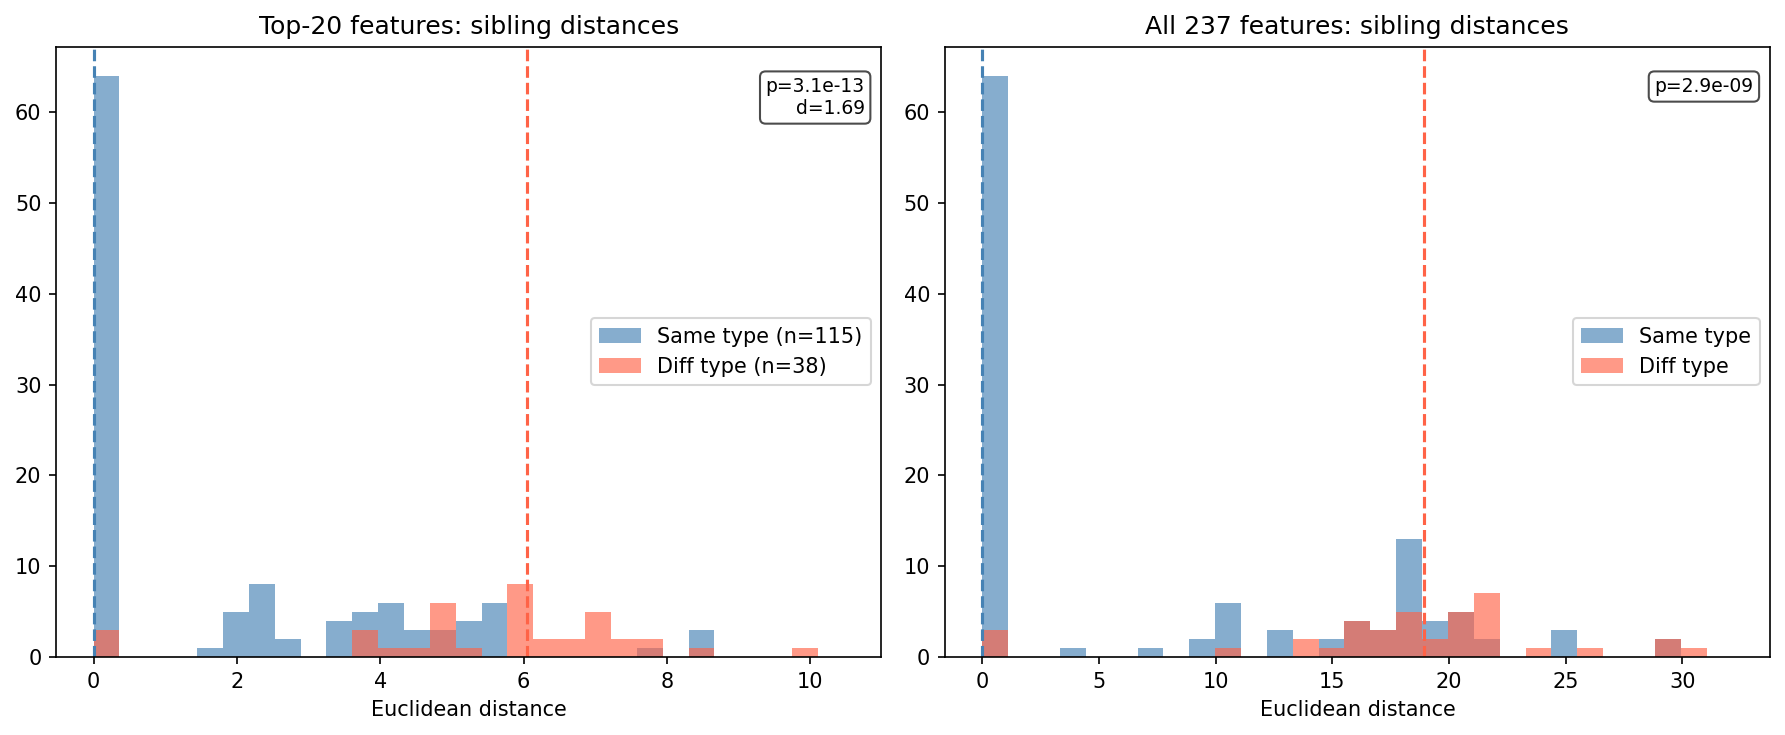


Interpretation: the top-20 features DO significantly separate same-type vs diff-type sibling pairs (p=3.15e-13).


In [16]:
# Pairwise distance sanity check on selected features
from scipy.stats import mannwhitneyu

# Build parent-children map
children_dict_lin = defaultdict(list)
def build_family(node, parent_name=None):
    name = map_names(node['did'])
    if parent_name is not None:
        children_dict_lin[parent_name].append(name)
    for child in node.get('children', []):
        build_family(child, name)
build_family(lineage_data)

# Collect terminal sibling pairs (across ALL cells)
all_name_to_idx = {name: i for i, name in enumerate(sample_names_all)}
terminal_set = set(sample_names_all[is_terminal])

sibling_pairs = []
for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            type_a = cell_type_dict.get(a)
            type_b = cell_type_dict.get(b)
            if type_a is None or type_b is None:
                continue
            sibling_pairs.append((a, b, type_a == type_b))

same_pairs = [(a, b) for a, b, s in sibling_pairs if s]
diff_pairs = [(a, b) for a, b, s in sibling_pairs if not s]

# Use full data (X_full, X_sel_full) not train-only (X, X_sel)
X_sel_full = X_full[:, top_k_idx]  # all 2126 cells x 20 genes

same_dists = np.array([np.linalg.norm(
    X_sel_full[all_name_to_idx[a]] - X_sel_full[all_name_to_idx[b]]
) for a, b in same_pairs])
diff_dists = np.array([np.linalg.norm(
    X_sel_full[all_name_to_idx[a]] - X_sel_full[all_name_to_idx[b]]
) for a, b in diff_pairs])

u_stat, p_mw = mannwhitneyu(same_dists, diff_dists, alternative='less')
pooled_std = np.sqrt((np.std(same_dists, ddof=1)**2 + np.std(diff_dists, ddof=1)**2) / 2)
cohen_d = (diff_dists.mean() - same_dists.mean()) / pooled_std

print(f'Terminal sibling pairs: same-type={len(same_pairs)}  diff-type={len(diff_pairs)}')
print(f'Same-type distance:  mean={same_dists.mean():.3f}  median={np.median(same_dists):.3f}')
print(f'Diff-type distance:  mean={diff_dists.mean():.3f}  median={np.median(diff_dists):.3f}')
print(f'Mann-Whitney U: p={p_mw:.2e}  Cohens d={cohen_d:.3f}')
print(f'Median ratio (diff/same): {np.median(diff_dists)/np.median(same_dists):.3f}')

# Compare with all features (full data)
same_all_d = np.array([np.linalg.norm(
    X_full[all_name_to_idx[a]] - X_full[all_name_to_idx[b]]
) for a, b in same_pairs])
diff_all_d = np.array([np.linalg.norm(
    X_full[all_name_to_idx[a]] - X_full[all_name_to_idx[b]]
) for a, b in diff_pairs])
u_all, p_all = mannwhitneyu(same_all_d, diff_all_d, alternative='less')
print(f'\nAll {X_full.shape[1]} features: same median={np.median(same_all_d):.3f}  ',
      f'diff median={np.median(diff_all_d):.3f}  p={p_all:.2e}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bins = np.linspace(0, max(same_dists.max(), diff_dists.max()) * 1.05, 30)
axes[0].hist(same_dists, bins=bins, alpha=0.65, color='steelblue', label=f'Same type (n={len(same_dists)})')
axes[0].hist(diff_dists, bins=bins, alpha=0.65, color='tomato', label=f'Diff type (n={len(diff_dists)})')
axes[0].axvline(np.median(same_dists), color='steelblue', ls='--')
axes[0].axvline(np.median(diff_dists), color='tomato', ls='--')
axes[0].set_title(f'Top-{K_SELECT} features: sibling distances')
axes[0].set_xlabel('Euclidean distance')
axes[0].legend()
axes[0].text(0.98, 0.95, f'p={p_mw:.1e}\nd={cohen_d:.2f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

bins2 = np.linspace(0, max(same_all_d.max(), diff_all_d.max()) * 1.05, 30)
axes[1].hist(same_all_d, bins=bins2, alpha=0.65, color='steelblue', label=f'Same type')
axes[1].hist(diff_all_d, bins=bins2, alpha=0.65, color='tomato', label=f'Diff type')
axes[1].axvline(np.median(same_all_d), color='steelblue', ls='--')
axes[1].axvline(np.median(diff_all_d), color='tomato', ls='--')
axes[1].set_title(f'All {X_full.shape[1]} features: sibling distances')
axes[1].set_xlabel('Euclidean distance')
axes[1].legend()
axes[1].text(0.98, 0.95, f'p={p_all:.1e}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig(RUN_DIR / 'sibling_pair_distances.png', dpi=150)
plt.show()

print(f'\nInterpretation: the top-{K_SELECT} features {"DO" if p_mw < 0.01 else "do NOT"}',
      f'significantly separate same-type vs diff-type sibling pairs (p={p_mw:.2e}).')


In [17]:
# Cross-species centroid analysis (linear model)

dominant_all = np.array([cell_types[t] for t in y_hard])

shared_types = []
for t in sorted(set(cell_types) - {'programmed_death'}):
    n_ele = ((dominant_all == t) & (species_all == 0)).sum()
    n_bri = ((dominant_all == t) & (species_all == 1)).sum()
    if n_ele >= 3 and n_bri >= 3:
        shared_types.append(t)

print(f'Shared types with >=3 cells in both species: {len(shared_types)}')
print(f'Types: {shared_types}')

# Centroid distances in full feature space
ele_centroids = {}
bri_centroids = {}
for t in shared_types:
    ele_centroids[t] = X_full[(dominant_all == t) & (species_all == 0)].mean(axis=0)
    bri_centroids[t] = X_full[(dominant_all == t) & (species_all == 1)].mean(axis=0)

rows = []
for t in shared_types:
    d_same = float(np.linalg.norm(ele_centroids[t] - bri_centroids[t]))
    d_ele_diff = []
    d_bri_diff = []
    for t2 in shared_types:
        if t2 != t:
            d_ele_diff.append(float(np.linalg.norm(ele_centroids[t] - ele_centroids[t2])))
            d_bri_diff.append(float(np.linalg.norm(bri_centroids[t] - bri_centroids[t2])))
    d_ele_mean = np.mean(d_ele_diff) if d_ele_diff else float('nan')
    d_bri_mean = np.mean(d_bri_diff) if d_bri_diff else float('nan')
    rows.append({
        'type': t, 'd_same': d_same,
        'd_diff_ele': d_ele_mean, 'd_diff_bri': d_bri_mean,
        'ratio_ele': d_same / d_ele_mean if d_ele_mean > 0 else float('nan'),
        'ratio_bri': d_same / d_bri_mean if d_bri_mean > 0 else float('nan'),
    })

df_cent = pd.DataFrame(rows).set_index('type')
print(df_cent.to_string(float_format=lambda x: f'{x:.4f}'))

better_ele = sum(1 for r in rows if r['ratio_ele'] < 1.0)
better_bri = sum(1 for r in rows if r['ratio_bri'] < 1.0)
n_types = len(rows)
print(f'\nTypes where d_same < d_diff_within: ele={better_ele}/{n_types}, bri={better_bri}/{n_types}')

# Also in selected feature space
X_sel_full = X_full[:, top_k_idx]
ele_sel = {}
bri_sel = {}
for t in shared_types:
    ele_sel[t] = X_sel_full[(dominant_all == t) & (species_all == 0)].mean(axis=0)
    bri_sel[t] = X_sel_full[(dominant_all == t) & (species_all == 1)].mean(axis=0)

sel_better_ele = sum(1 for t in shared_types if
    float(np.linalg.norm(ele_sel[t] - bri_sel[t])) <
    np.mean([float(np.linalg.norm(ele_sel[t] - ele_sel[t2])) for t2 in shared_types if t2 != t]))
sel_better_bri = sum(1 for t in shared_types if
    float(np.linalg.norm(ele_sel[t] - bri_sel[t])) <
    np.mean([float(np.linalg.norm(bri_sel[t] - bri_sel[t2])) for t2 in shared_types if t2 != t]))
print(f'Top-{K_SELECT} features: d_same < d_diff: ele={sel_better_ele}/{n_types}, bri={sel_better_bri}/{n_types}')


Shared types with >=3 cells in both species: 9
Types: ['alimentary', 'coelomocyte', 'epithelium', 'excretory', 'glial', 'muscle', 'neuron', 'other', 'reproduction']
              d_same  d_diff_ele  d_diff_bri  ratio_ele  ratio_bri
type                                                              
alimentary    4.3271     11.3635     11.7988     0.3808     0.3667
coelomocyte  11.4840     11.5838     14.6776     0.9914     0.7824
epithelium    3.0272      9.5321     10.1312     0.3176     0.2988
excretory    11.1126     13.6799     12.7753     0.8123     0.8699
glial         5.6424     10.1776     10.9561     0.5544     0.5150
muscle        2.6658      9.7915     10.0020     0.2723     0.2665
neuron        1.7245      9.3397      9.8546     0.1846     0.1750
other         4.7828      9.8303     10.3350     0.4865     0.4628
reproduction  7.7411     11.3582     11.6596     0.6815     0.6639

Types where d_same < d_diff_within: ele=9/9, bri=9/9
Top-20 features: d_same < d_diff: ele=9/9, b